In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\supri\Desktop\ML project\bengaluru_house_prices.csv")

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df['size'].fillna('0 BHK', inplace=True)
df['bath']=df['bath'].fillna(0)
df['balcony']=df['balcony'].fillna(0)

C:\Users\supri\AppData\Local\Temp\ipykernel_18868\1483536262.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['size'].fillna('0 BHK', inplace=True)


In [6]:
df.isnull().sum()

area_type          0
availability       0
location           1
size               0
society         5502
total_sqft         0
bath               0
balcony            0
price              0
dtype: int64

In [7]:
df = df[df['society'].notna()]

In [8]:
df.isnull().sum()

area_type       0
availability    0
location        1
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [9]:
df['total_sqft']=pd.to_numeric(df['total_sqft'], errors='coerce')
df['total_sqft']=df['total_sqft'].fillna(0)

In [10]:
df.describe()

,total_sqft,bath,balcony,price
count,7818.000000,7818.000000,7818.000000,7818.000000
mean,1499.267047,2.475058,1.563060,101.449896
std,996.102316,0.970964,0.829559,116.418437
min,0.000000,0.000000,0.000000,8.000000
25%,1105.000000,2.000000,1.000000,50.000000
50%,1310.000000,2.000000,2.000000,70.000000
75%,1675.000000,3.000000,2.000000,110.000000
max,36000.000000,18.000000,3.000000,2700.000000


Text(0.5, 1.0, 'Distribution of House Prices')

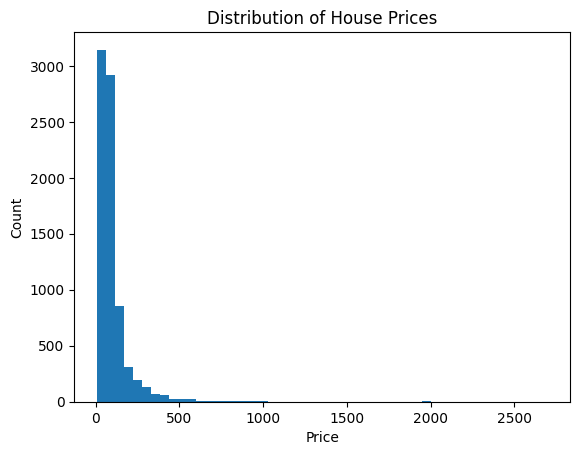

In [11]:
import matplotlib.pyplot as plt
plt.hist(df['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of House Prices')

Text(0.5, 1.0, 'Distribution of Total Square Feet')

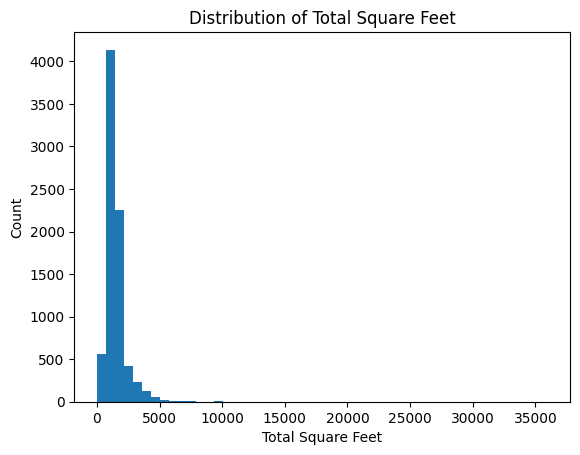

In [12]:
plt.hist(df['total_sqft'], bins=50)
plt.xlabel('Total Square Feet')
plt.ylabel('Count')
plt.title('Distribution of Total Square Feet')

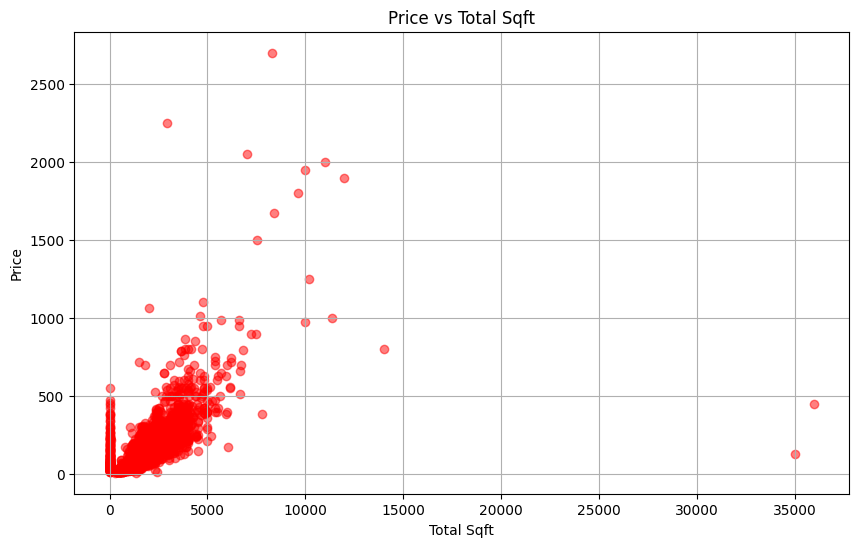

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(df['total_sqft'], df['price'], alpha=0.5, color='red')
plt.xlabel('Total Sqft')
plt.ylabel('Price')
plt.title('Price vs Total Sqft')
plt.grid(True)
plt.show()

In [14]:
df.describe()

,total_sqft,bath,balcony,price
count,7818.000000,7818.000000,7818.000000,7818.000000
mean,1499.267047,2.475058,1.563060,101.449896
std,996.102316,0.970964,0.829559,116.418437
min,0.000000,0.000000,0.000000,8.000000
25%,1105.000000,2.000000,1.000000,50.000000
50%,1310.000000,2.000000,2.000000,70.000000
75%,1675.000000,3.000000,2.000000,110.000000
max,36000.000000,18.000000,3.000000,2700.000000


In [15]:
q1= df['price'].quantile(0.25)
q3= df['price'].quantile(0.75)
iqr= q3 - q1
iqr

np.float64(60.0)

In [16]:
lower_bound= q1 - 1.5 * iqr
upper_bound= q3 + 1.5 * iqr
lower_bound, upper_bound

(np.float64(-40.0), np.float64(200.0))

In [17]:
df1= df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
df1

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170.0,2.0,1.0,38.00
12,Super built-up Area,Ready To Move,7th Phase JP Nagar,2 BHK,Shncyes,1000.0,2.0,1.0,38.00
...,...,...,...,...,...,...,...,...,...
13308,Built-up Area,Ready To Move,Bannerghatta Road,3 BHK,Baanise,1527.0,3.0,1.0,142.00
13309,Super built-up Area,Ready To Move,Yeshwanthpur,3 BHK,IBityin,1675.0,3.0,0.0,92.13
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345.0,2.0,1.0,57.00
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715.0,3.0,3.0,112.00


In [18]:
df.shape[0]- df1.shape[0]

670

In [19]:
print(df1.describe())
print(df.describe())

         total_sqft         bath      balcony        price
count   7148.000000  7148.000000  7148.000000  7148.000000
mean    1334.250990     2.323727     1.558478    75.979195
std      619.403264     0.770494     0.800566    38.128770
min        0.000000     0.000000     0.000000     8.000000
25%     1096.000000     2.000000     1.000000    48.000000
50%     1270.000000     2.000000     2.000000    66.500000
75%     1570.000000     3.000000     2.000000    95.000000
max    35000.000000    18.000000     3.000000   200.000000
         total_sqft         bath      balcony        price
count   7818.000000  7818.000000  7818.000000  7818.000000
mean    1499.267047     2.475058     1.563060   101.449896
std      996.102316     0.970964     0.829559   116.418437
min        0.000000     0.000000     0.000000     8.000000
25%     1105.000000     2.000000     1.000000    50.000000
50%     1310.000000     2.000000     2.000000    70.000000
75%     1675.000000     3.000000     2.000000   110.0000

In [20]:
df.isnull().sum()

area_type       0
availability    0
location        1
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [21]:
df1.dtypes

area_type        object
availability     object
location         object
size             object
society          object
total_sqft      float64
bath            float64
balcony         float64
price           float64
dtype: object

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorial_features = ['area_type','availability', 'location',  'size','society',]

numerical_features = ['total_sqft', 'bath', 'balcony']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorial_features)
    ])


In [23]:
x=df1.drop('price', axis='columns')
y=df1['price']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [24]:
print(X_train.dtypes)
print(X_train.columns)
print(X_train.isna().sum())
print(y_train.isna().sum())

area_type        object
availability     object
location         object
size             object
society          object
total_sqft      float64
bath            float64
balcony         float64
dtype: object
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony'],
      dtype='object')
area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
bath            0
balcony         0
dtype: int64
0


In [25]:
from sklearn. linear_model import LinearRegression
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', LinearRegression())])

In [26]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
print(model.score(X_test, y_test))
print(model.score(X_train, y_train))

0.7948582101810979
0.944322255902033


In [28]:
from sklearn.linear_model import Lasso
lasso = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', Lasso(alpha=0.1,max_iter=2000,tol=0.01))
                        ])
lasso.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
print(lasso.score(X_train, y_train))
print(lasso.score(X_test, y_test))

0.5502356195146605
0.5947172256191926


In [30]:
from sklearn.linear_model import Ridge
ridge = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', Ridge(alpha=1.0, max_iter=2000, tol=0.01))
                        ])
ridge.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
print(ridge.score(X_test, y_test))
print(ridge.score(X_train, y_train))
print(model.score(X_test, y_test))
print(model.score(X_train, y_train))

0.792497463078263
0.8825298520249527
0.7948582101810979
0.944322255902033


In [32]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x, y, cv=10)
print(scores.mean())

0.764292962068198


In [33]:
import joblib
joblib.dump(model, 'house_price_model.pkl')

['house_price_model.pkl']